# 🚁 M3: Drone vs Bird Detector Training
**Computer Vision | Group Project | IE University MBDS-SEP25**

**Scope:** Transfer-learned object detector

This notebook fine-tunes a YOLOv11 detector to classify **drone vs bird** using transfer learning from COCO-pretrained weights. We train two model scales, YOLOv11s and YOLOv11n, and compare their accuracy and inference speed, covering both the mandatory detection requirement and the scale-comparison bonus.

**Why transfer learning?**
YOLOv11 was pretrained on COCO (80 classes, ~118,000 images). Its backbone already encodes edges, textures, and the shapes of moving objects. Fine-tuning only the detection head for our two classes is far more practical than training from scratch, which would overfit badly on 1,950 images.

**Why YOLOv11 and not an older version?**
YOLOv11 (Ultralytics, 2024) improves on YOLOv8 in small-object detection, which matters here since drones and birds at a distance are often smaller than 32×32 px.

## ⚙️ 0 · Environment Setup

In [1]:
# Pinning ultralytics to a major version so a future breaking release doesn't silently install.
!pip install -q "ultralytics>=8.3.0,<9.0.0" "PyYAML>=6.0" "matplotlib>=3.7.0"

import ultralytics
print(f"Ultralytics version: {ultralytics.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 45.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.4.74


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import shutil

# Path constants: update this block if the Drive layout ever changes.
DRIVE_ROOT = "/content/drive/MyDrive/!CVIS"
DATA_DIR   = f"{DRIVE_ROOT}/data/processed"   # train/ val/ test/ + data.yaml
DATA_YAML  = f"{DATA_DIR}/data.yaml"
MODELS_DIR = f"{DRIVE_ROOT}/models"           # shared with M4 (evaluation) and M5 (tracking)
RUNS_DIR   = f"{DRIVE_ROOT}/runs"             # YOLO output: weights, plots, metrics CSVs

# Check the dataset exists BEFORE creating any output folders.
# os.makedirs would otherwise create an empty !CVIS in My Drive and mask a wrong/missing mount.
assert os.path.isdir(DATA_DIR), (
    f"Dataset directory not found: {DATA_DIR}\n"
    "The !CVIS folder is shared by a teammate. In Google Drive, open 'Shared with me',\n"
    "right-click !CVIS, choose 'Add shortcut to Drive', place it in My Drive, then\n"
    "'Runtime > Disconnect and delete runtime' and re-run from the top."
)
assert os.path.exists(DATA_YAML), f"data.yaml not found at {DATA_YAML}"

# Dataset confirmed; now create the output folders.
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RUNS_DIR,   exist_ok=True)

# Verify the dataset structure before starting a training run.
for split in ["train", "val", "test"]:
    n_imgs = len(os.listdir(f"{DATA_DIR}/{split}/images"))
    n_lbs  = len(os.listdir(f"{DATA_DIR}/{split}/labels"))
    print(f"  {split:5s}: {n_imgs} images, {n_lbs} labels")
    assert n_imgs == n_lbs, (
        f"{split}: image/label count mismatch ({n_imgs} vs {n_lbs}) — "
        "check for missing or extra files."
    )

print(f"\n✅ Dataset OK. data.yaml at: {DATA_YAML}")

  train: 1950 images, 1950 labels
  val  : 555 images, 555 labels
  test : 278 images, 278 labels

✅ Dataset OK. data.yaml at: /content/drive/MyDrive/!CVIS/data/processed/data.yaml


## 🛠️ 1 · Training Configuration & Hyperparameter Rationale

All hyperparameters are declared explicitly, as required by the assignment.

| Parameter | Value | Rationale |
|---|---|---|
| `epochs` | 50 | Enough to fine-tune a pretrained backbone on ~2,000 images without overfitting |
| `batch` | 16 | Fits Colab T4 VRAM (15 GB) at imgsz=640; larger batches stabilise gradient updates |
| `imgsz` | 640 | YOLO standard; 1,280 helps small objects but roughly doubles VRAM usage |
| `optimizer` | AdamW | Adam with weight decay; consistently outperforms SGD for fine-tuning tasks |
| `lr0` | 0.001 | Initial learning rate, lower than the from-scratch default (0.01) since the backbone is already pretrained |
| `lrf` | 0.01 | Final LR = lr0 × lrf = 1e-5, following a cosine decay schedule |
| `momentum` | 0.937 | AdamW beta1; YOLO default, well-validated across detection tasks |
| `weight_decay` | 0.0005 | L2 regularisation to reduce overfitting on the small dataset |
| `warmup_epochs` | 3 | Ramps LR from near-zero to lr0, preventing early instability with pretrained weights |
| `mosaic` | 1.0 | Tiles 4 images together so the model sees drones and birds in varied backgrounds |
| `copy_paste` | 0.3 | Pastes bird instances onto other images to compensate for bird being the minority class (~37% of boxes) |
| `hsv_h/s/v` | 0.015/0.7/0.4 | Colour jitter for robustness to lighting and sensor variation |
| `fliplr` | 0.5 | Drones and birds are horizontally symmetric, so this effectively doubles the training data |
| `flipud` | 0.0 | Disabled: aerial imagery has a clear up/down orientation |

**Loss functions** (built into YOLO, not user-configurable):
- **Box loss (CIoU):** penalises misaligned bounding boxes
- **Classification loss (BCE):** binary cross-entropy per class
- **Distribution Focal Loss (DFL):** regresses box-edge distributions for precise localisation

In [5]:
# Shared hyperparameter dict: changing a value here applies to both model runs.
SHARED_HP = dict(
    data          = DATA_YAML,
    epochs        = 50,
    batch         = 16,
    imgsz         = 640,
    optimizer     = "AdamW",
    lr0           = 0.001,
    lrf           = 0.01,
    momentum      = 0.937,
    weight_decay  = 0.0005,
    warmup_epochs = 3,
    mosaic        = 1.0,
    copy_paste    = 0.3,
    hsv_h         = 0.015,
    hsv_s         = 0.7,
    hsv_v         = 0.4,
    fliplr        = 0.5,
    flipud        = 0.0,
    seed          = 42,     # fixed seed for reproducibility across runs
    workers       = 2,      # Colab's DataLoader is unstable with the default of 8
    project       = RUNS_DIR,
    save          = True,
    plots         = True,
    verbose       = True,
)
print("Hyperparameters confirmed:", SHARED_HP)

Hyperparameters confirmed: {'data': '/content/drive/MyDrive/!CVIS/data/processed/data.yaml', 'epochs': 50, 'batch': 16, 'imgsz': 640, 'optimizer': 'AdamW', 'lr0': 0.001, 'lrf': 0.01, 'momentum': 0.937, 'weight_decay': 0.0005, 'warmup_epochs': 3, 'mosaic': 1.0, 'copy_paste': 0.3, 'hsv_h': 0.015, 'hsv_s': 0.7, 'hsv_v': 0.4, 'fliplr': 0.5, 'flipud': 0.0, 'seed': 42, 'workers': 2, 'project': '/content/drive/MyDrive/!CVIS/runs', 'save': True, 'plots': True, 'verbose': True}


## 🏋️ 2 · Train YOLOv11s (Primary Model)

**YOLOv11s** (small): 9.4 M parameters. This is the primary model whose `best.pt` will be shared with the evaluation pillar (M4) and the tracking pillar (M5).

In [6]:
from ultralytics import YOLO

# yolo11s.pt is downloaded automatically from Ultralytics (COCO pretrained)
model_s = YOLO("yolo11s.pt")

results_s = model_s.train(
    name = "drone_bird_v1_s",
    **SHARED_HP
)

print("\n✅ YOLOv11s training complete.")
print(f"   Best weights: {results_s.save_dir}/weights/best.pt")

Ultralytics 8.4.74 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/!CVIS/data/processed/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=drone_bird_v1_s, nbs=64, nms=False, opset=None, optimize=False, optimizer=Ada

In [7]:
# Copy best.pt to the shared Drive location — unblocks M4 (evaluation) and M5 (tracking)
best_s_src = f"{results_s.save_dir}/weights/best.pt"
best_s_dst = f"{MODELS_DIR}/best_s.pt"
assert os.path.exists(best_s_src), f"best.pt not found — did training complete? ({best_s_src})"
shutil.copy(best_s_src, best_s_dst)
print(f"✅ YOLOv11s best.pt saved to Drive: {best_s_dst}")

✅ YOLOv11s best.pt saved to Drive: /content/drive/MyDrive/!CVIS/models/best_s.pt


## ⚡ 3 · Train YOLOv11n (Scale-Comparison Bonus)

**YOLOv11n** (nano): 2.6 M parameters, roughly 3.5x fewer than YOLOv11s. We use identical hyperparameters to keep the comparison fair.

**What we are testing:** whether the accuracy drop from s to n is acceptable given the speed gain. In a real counter-UAV system, latency matters: a detector that is even 0.3 s slower could miss a fast-moving drone.

In [8]:
model_n = YOLO("yolo11n.pt")

results_n = model_n.train(
    name = "drone_bird_v1_n",
    **SHARED_HP
)

print("\n✅ YOLOv11n training complete.")
print(f"   Best weights: {results_n.save_dir}/weights/best.pt")

Ultralytics 8.4.74 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/!CVIS/data/processed/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=drone_bird_v1_n, nbs=64, nms=False, opset=None, optimize=False, optimizer=Ada

In [9]:
best_n_src = f"{results_n.save_dir}/weights/best.pt"
best_n_dst = f"{MODELS_DIR}/best_n.pt"
assert os.path.exists(best_n_src), f"best.pt not found — did training complete? ({best_n_src})"
shutil.copy(best_n_src, best_n_dst)
print(f"✅ YOLOv11n best.pt saved to Drive: {best_n_dst}")

✅ YOLOv11n best.pt saved to Drive: /content/drive/MyDrive/!CVIS/models/best_n.pt


## 📊 4 · Results & Scale Comparison

YOLO auto-generates loss curves, a confusion matrix, and a PR curve during training. We display them and build a side-by-side comparison table (mAP, FPS, model size).


  YOLOv11s: Primary Model

--- results.png ---


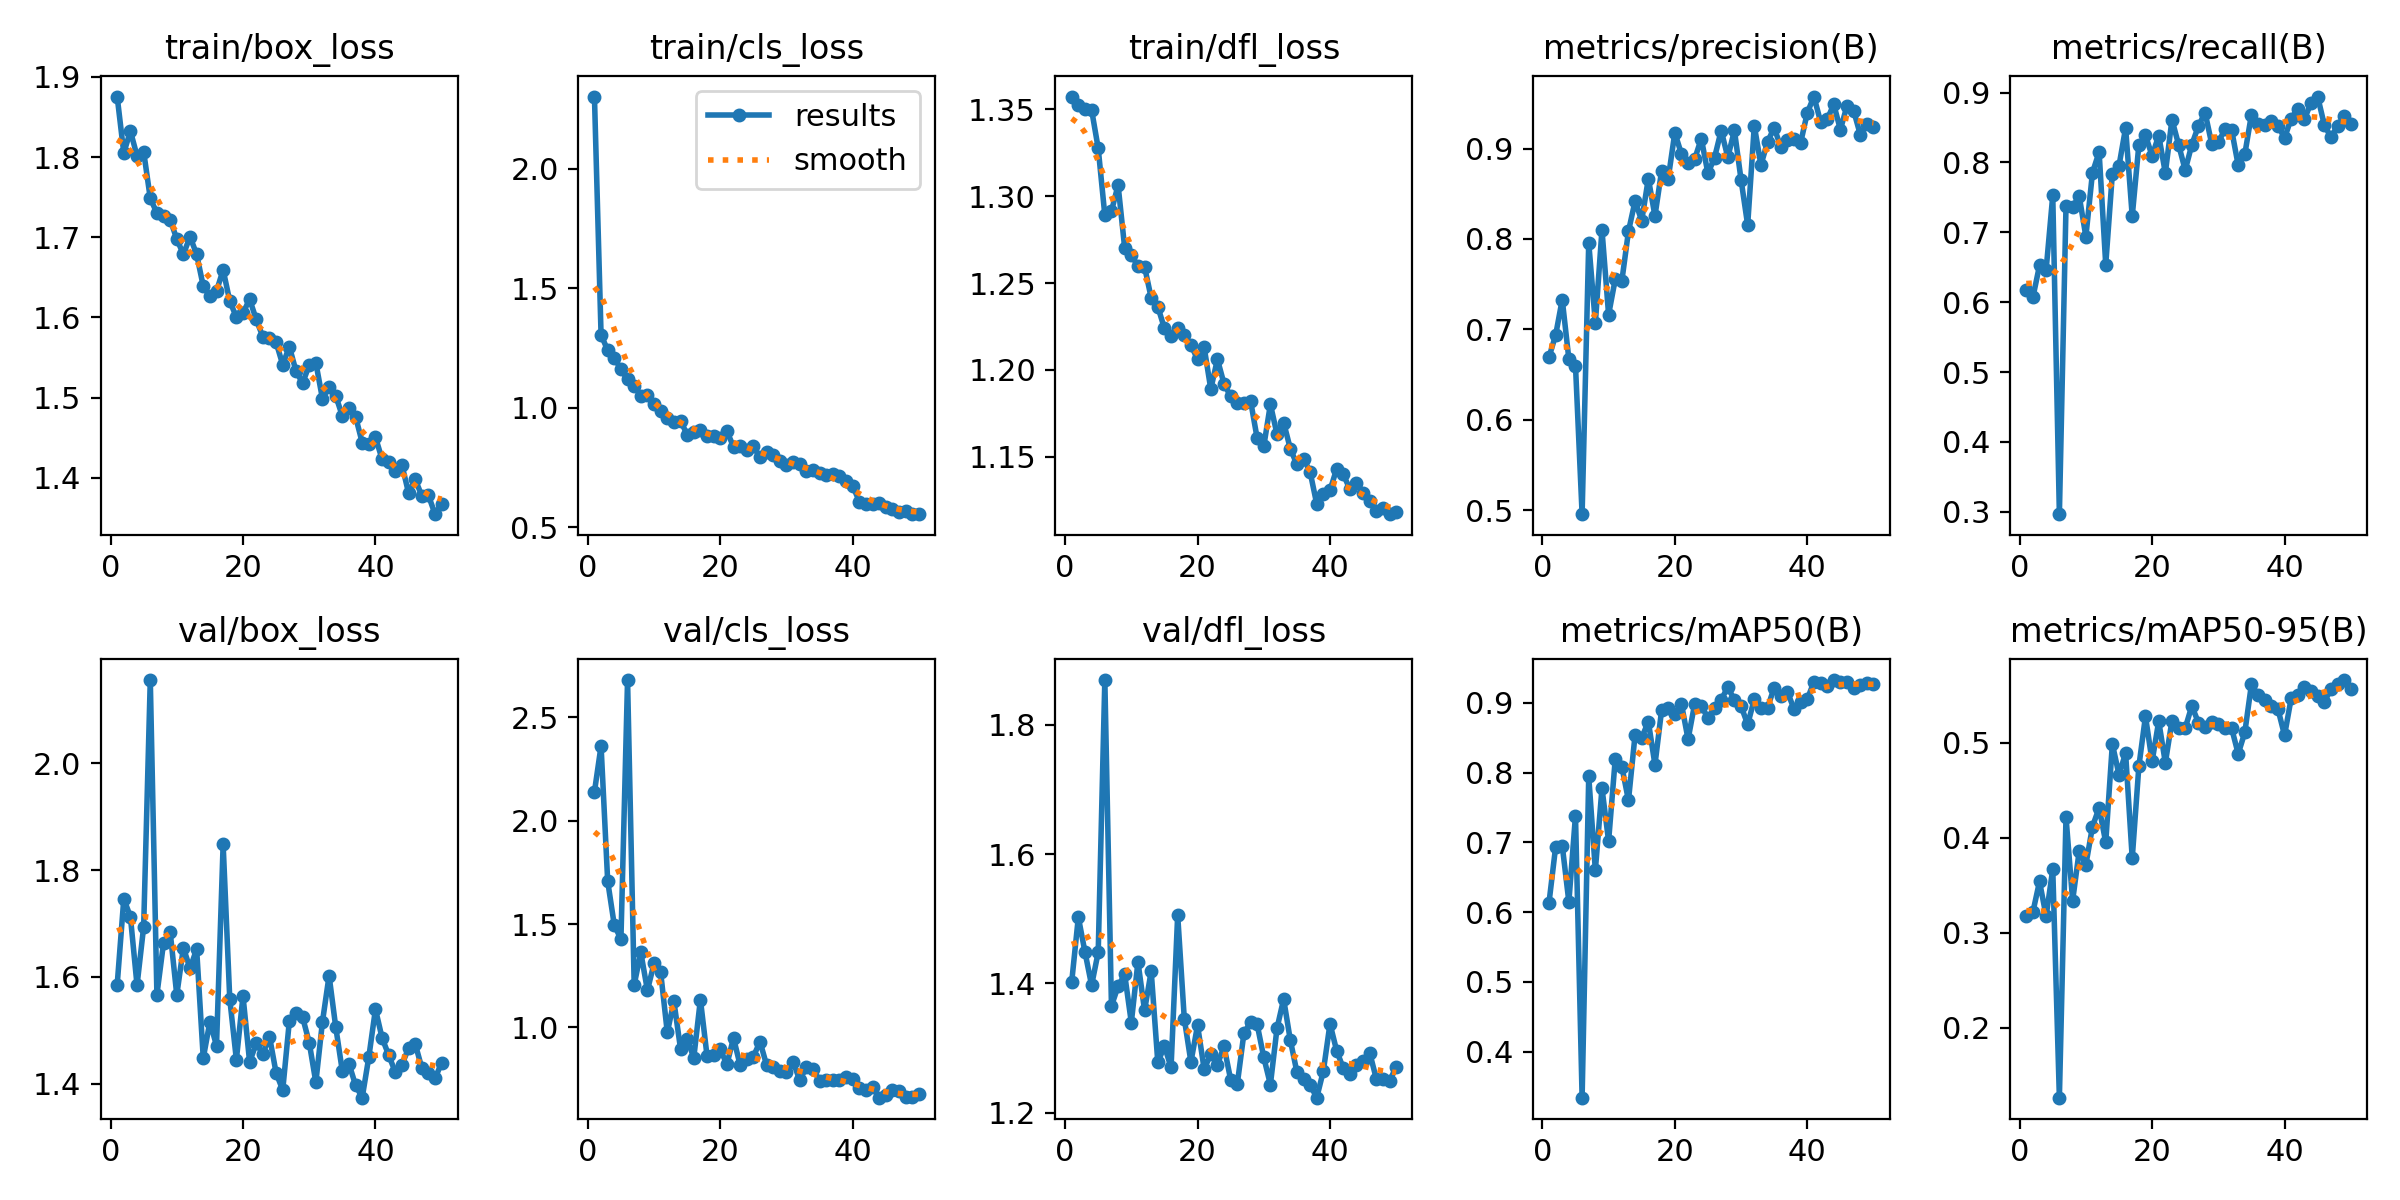


--- confusion_matrix_normalized.png ---


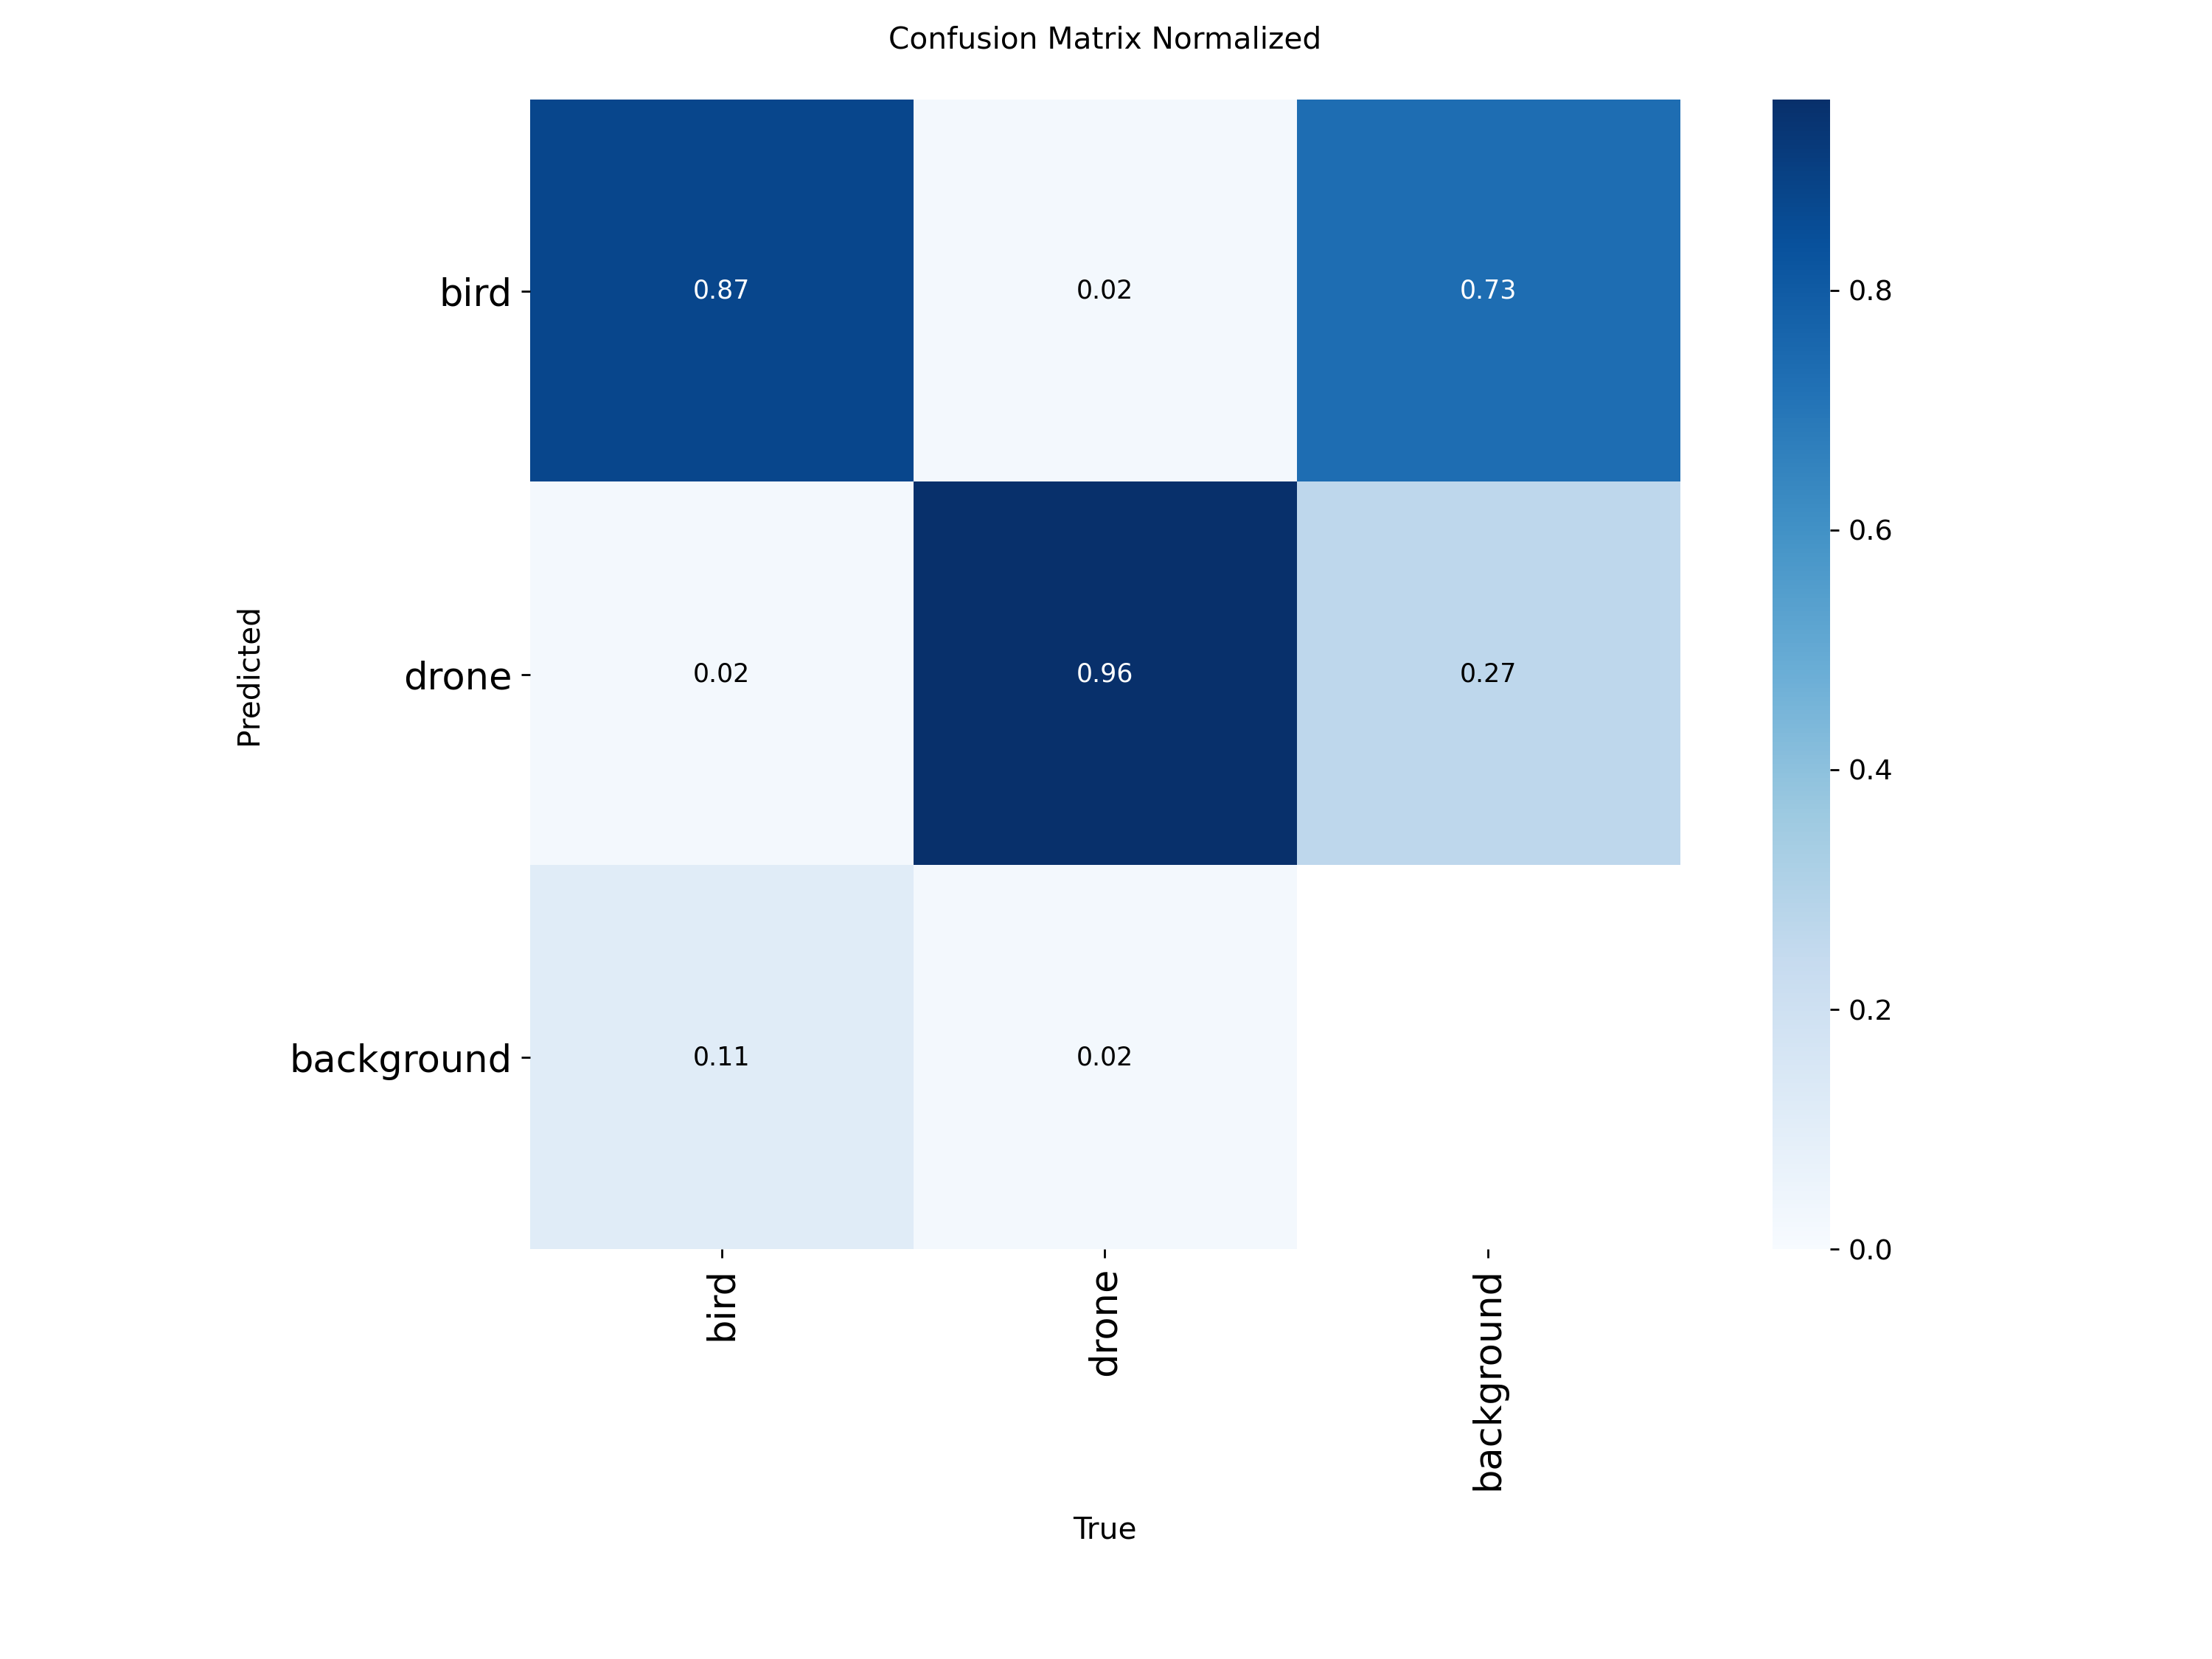

  (not found: PR_curve.png)

  YOLOv11n: Nano (Scale Comparison)

--- results.png ---


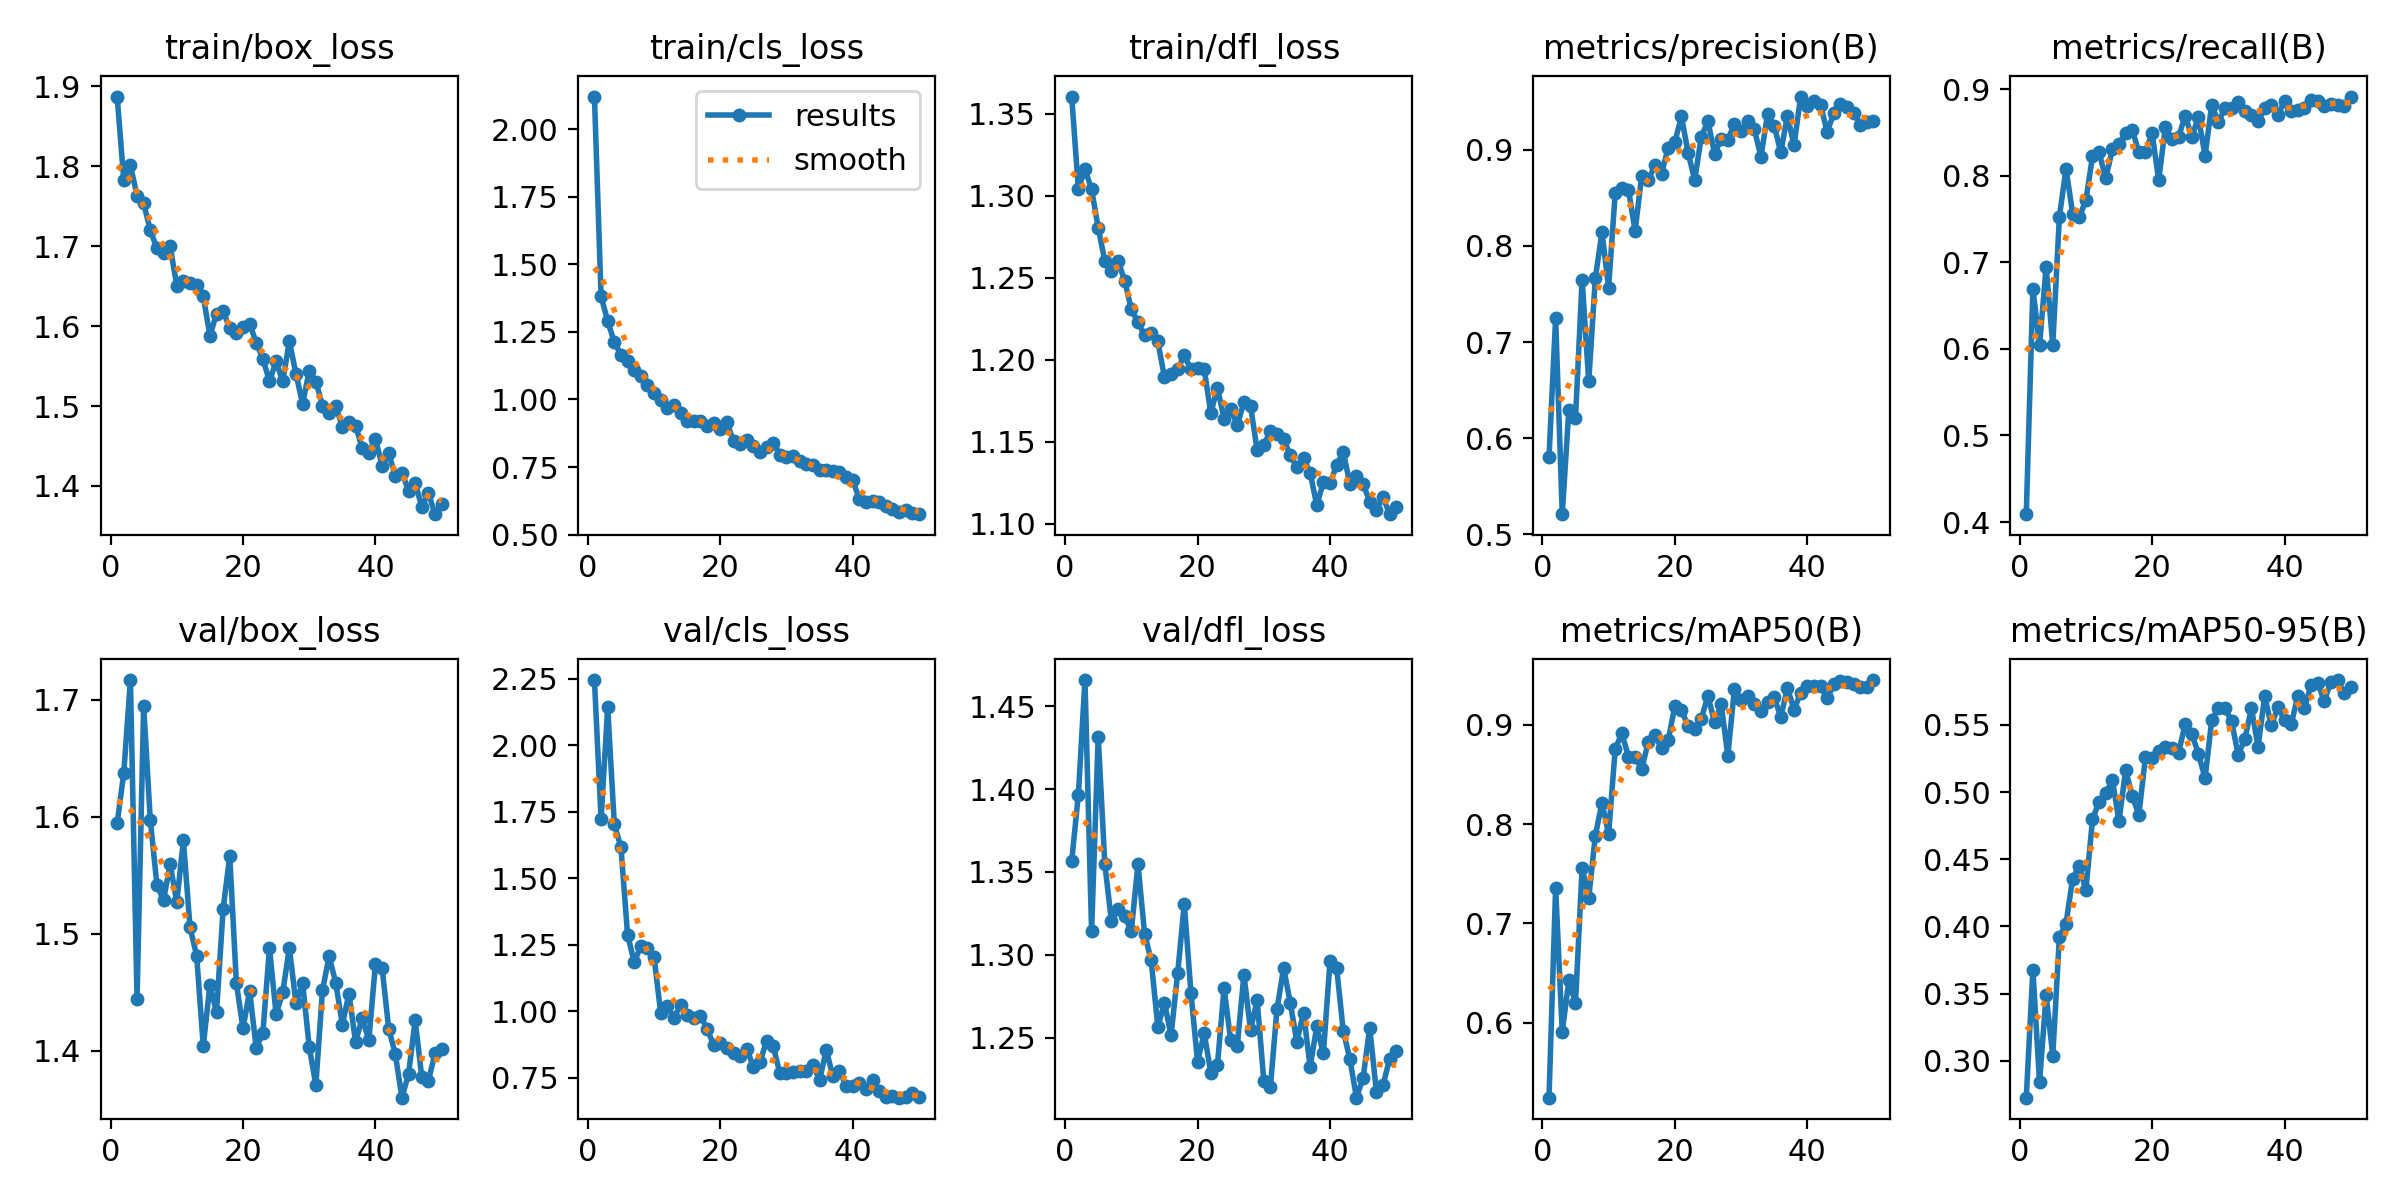


--- confusion_matrix_normalized.png ---


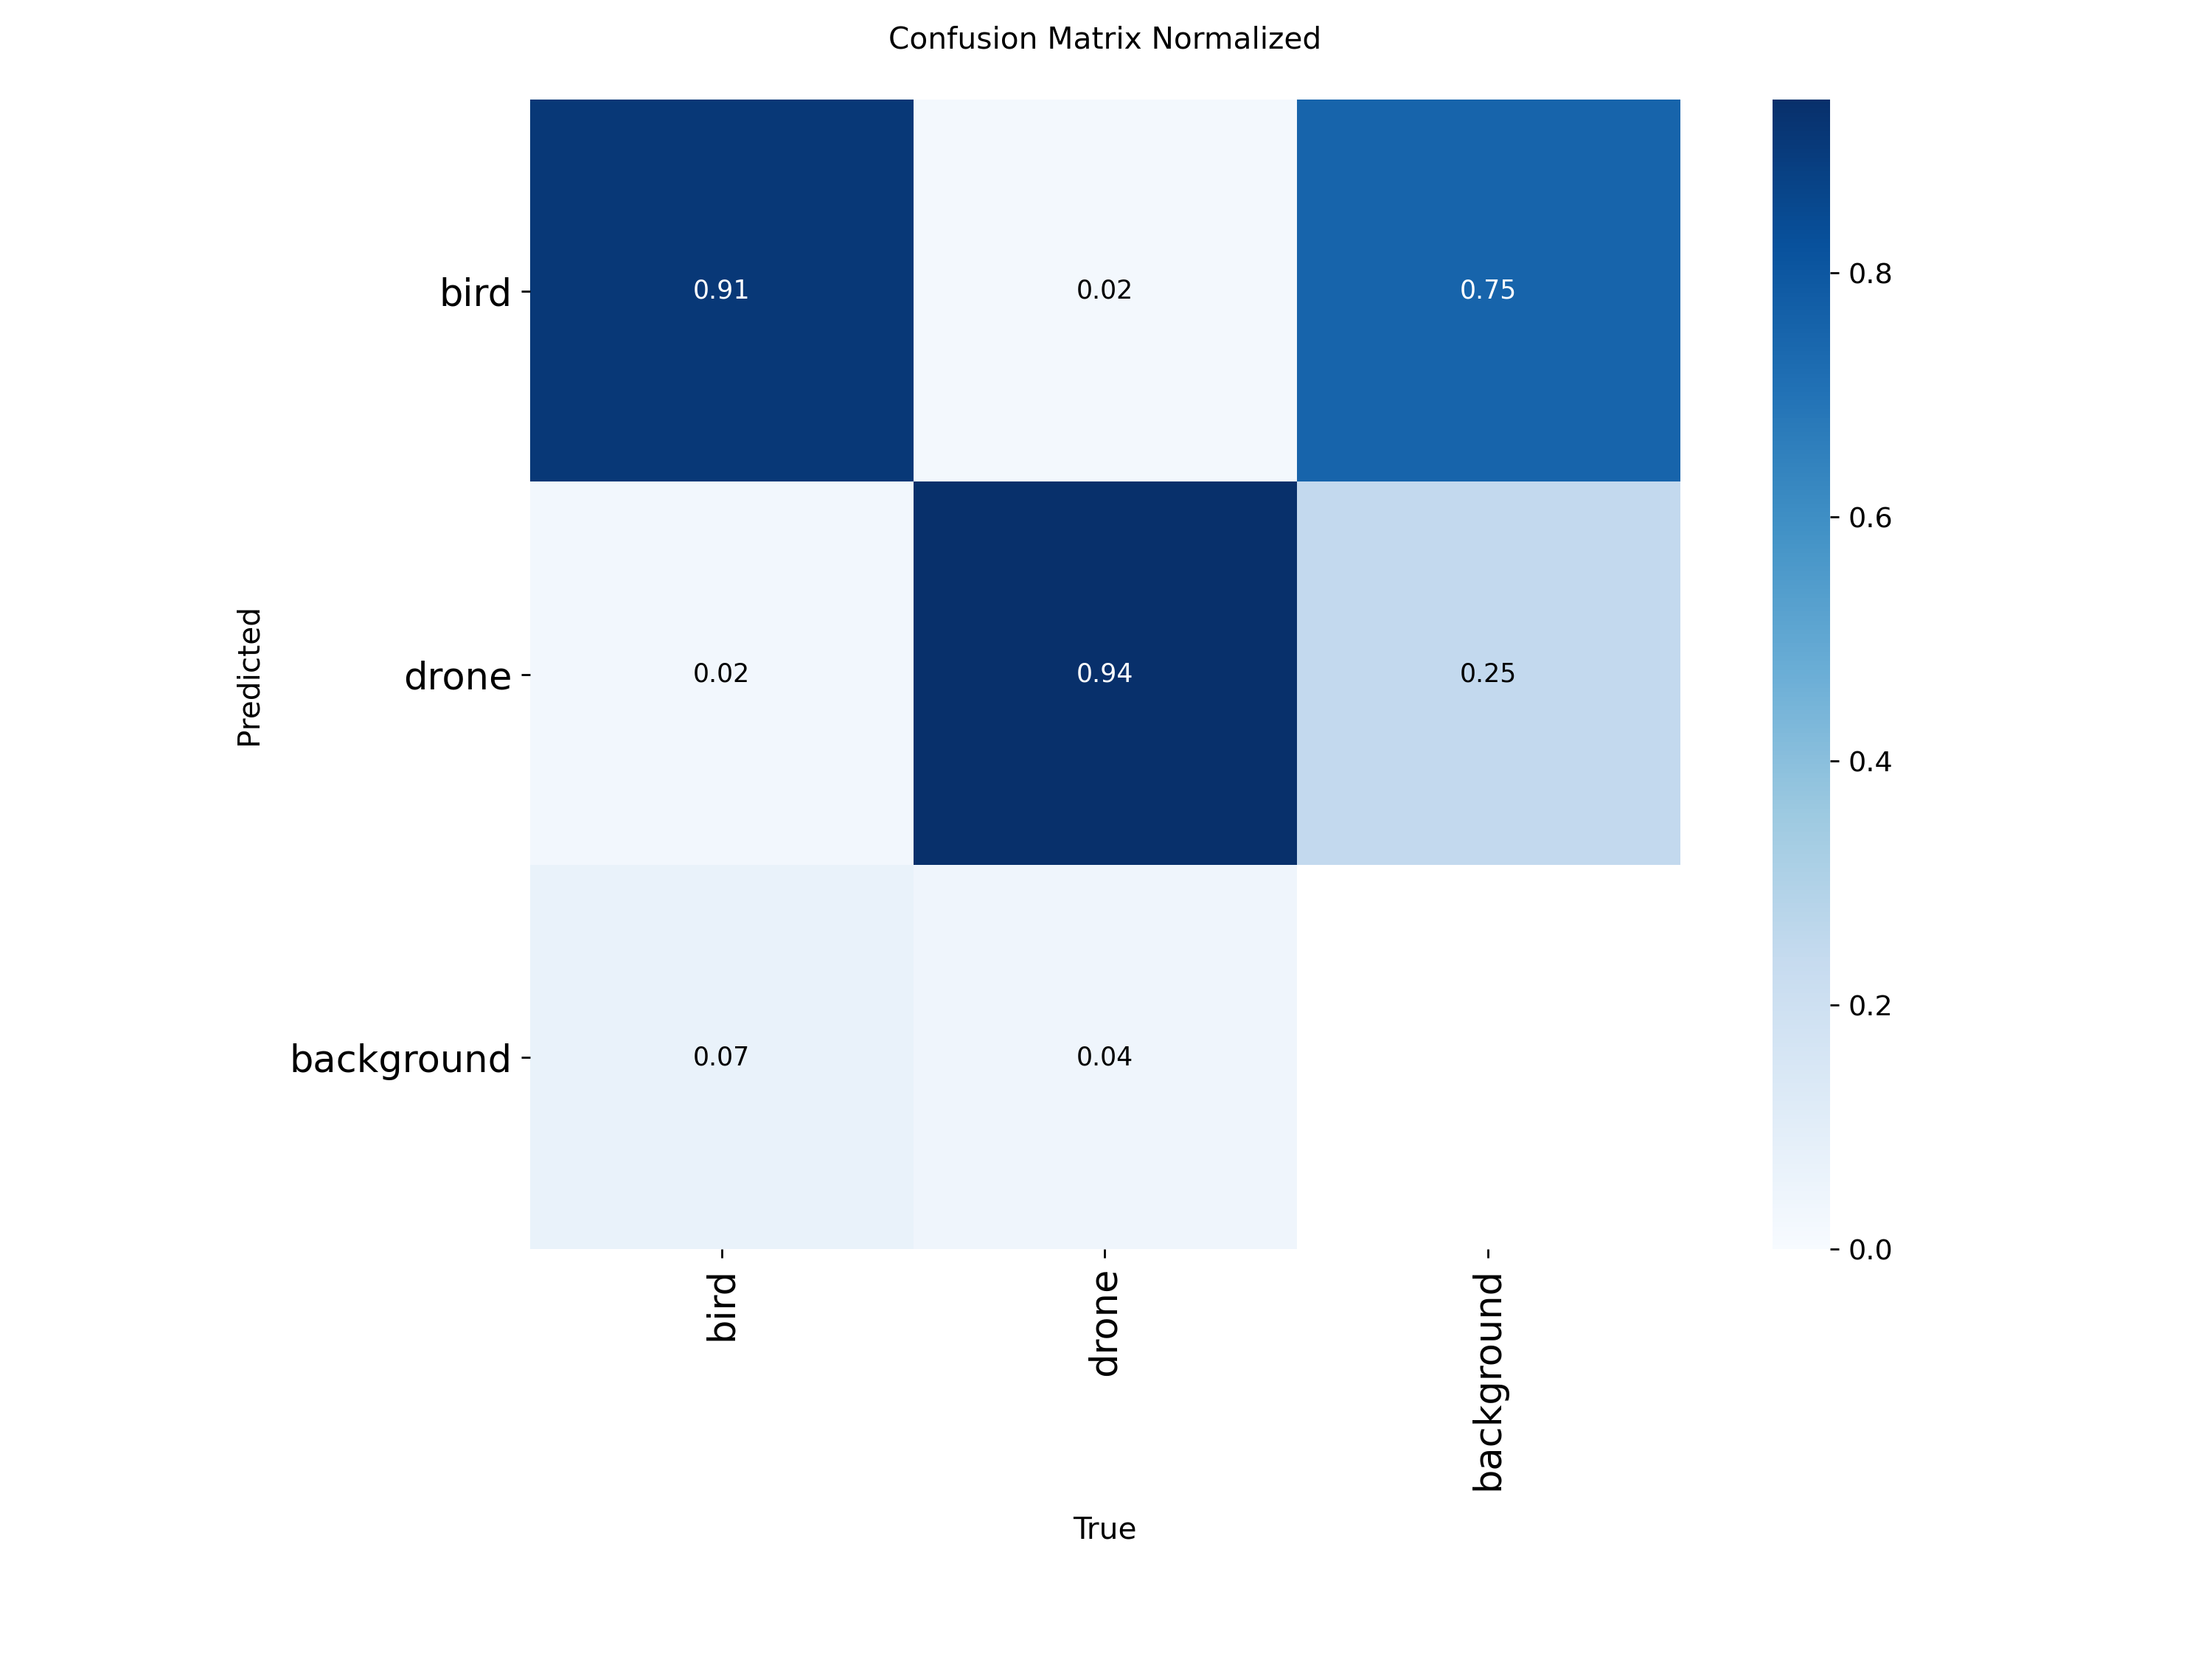

  (not found: PR_curve.png)


In [10]:
from IPython.display import Image as IPImage, display

def show_run_plots(run_dir, label):
    print(f"\n{'='*60}\n  {label}\n{'='*60}")
    for fname in ["results.png", "confusion_matrix_normalized.png", "PR_curve.png"]:
        fpath = os.path.join(str(run_dir), fname)
        if os.path.exists(fpath):
            print(f"\n--- {fname} ---")
            display(IPImage(fpath, width=800))
        else:
            print(f"  (not found: {fname})")

show_run_plots(results_s.save_dir, "YOLOv11s: Primary Model")
show_run_plots(results_n.save_dir, "YOLOv11n: Nano (Scale Comparison)")

In [11]:
import time
import torch

def get_val_metrics(results):
    d = results.results_dict
    return {
        "mAP50":     round(d.get("metrics/mAP50(B)",     0), 4),
        "mAP50-95":  round(d.get("metrics/mAP50-95(B)",  0), 4),
        "Precision": round(d.get("metrics/precision(B)", 0), 4),
        "Recall":    round(d.get("metrics/recall(B)",    0), 4),
    }

def measure_fps(model, runs=50, imgsz=640):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    dummy  = torch.zeros(1, 3, imgsz, imgsz).to(device)
    for _ in range(5):
        model.predict(source=dummy, verbose=False)
    t0 = time.perf_counter()
    for _ in range(runs):
        model.predict(source=dummy, verbose=False)
    return round(runs / (time.perf_counter() - t0), 1)

m_s   = get_val_metrics(results_s)
m_n   = get_val_metrics(results_n)
fps_s = measure_fps(YOLO(best_s_dst))
fps_n = measure_fps(YOLO(best_n_dst))
sz_s  = round(os.path.getsize(best_s_dst) / 1e6, 1)
sz_n  = round(os.path.getsize(best_n_dst) / 1e6, 1)

rows = [("mAP50",     m_s["mAP50"],     m_n["mAP50"]),
        ("mAP50-95",  m_s["mAP50-95"],  m_n["mAP50-95"]),
        ("Precision", m_s["Precision"], m_n["Precision"]),
        ("Recall",    m_s["Recall"],    m_n["Recall"]),
        ("FPS (T4)",  fps_s,            fps_n),
        ("Size (MB)", sz_s,             sz_n)]

print(f"\n{'Metric':<14} {'YOLOv11s':>12} {'YOLOv11n':>12}")
print("-" * 40)
for name, vs, vn in rows:
    print(f"{name:<14} {vs:>12} {vn:>12}")

print("\nNote: these are val-set metrics. Test-set evaluation is in notebook 03 (M4 — evaluation).")


Metric             YOLOv11s     YOLOv11n
----------------------------------------
mAP50                0.9291       0.9378
mAP50-95             0.5658       0.5821
Precision            0.9277       0.9257
Recall               0.8662        0.882
FPS (T4)               90.6        114.5
Size (MB)              19.2          5.5

Note: these are val-set metrics. Test-set evaluation is in notebook 03 (M4 — evaluation).


## 🔍 5 · Quick Inference Visual Check

Before handing off `best.pt`, visually confirm:
- Boxes land on actual objects, not background
- Labels correctly show `bird` or `drone`
- Confidence scores look reasonable (above 0.3)

Results saved to /content/drive/.shortcut-targets-by-id/18AdH-Pocf5ey83Iw2ifVeb6Z2pCsKRSB/!CVIS/runs/inference_check/val_sample


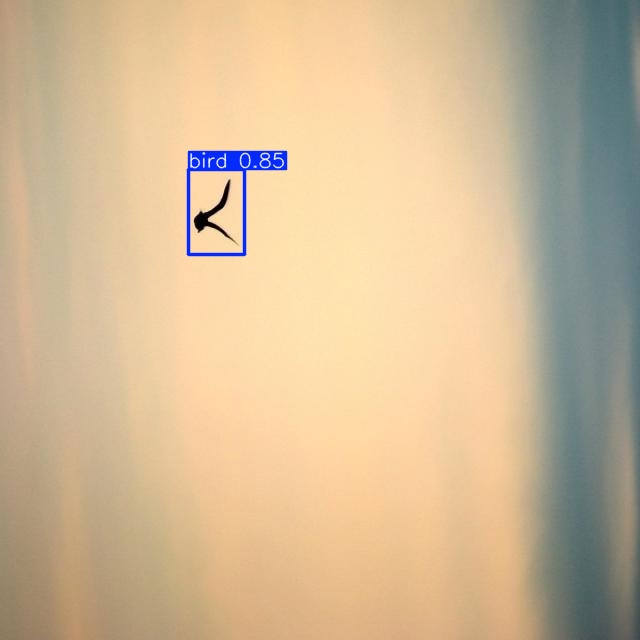

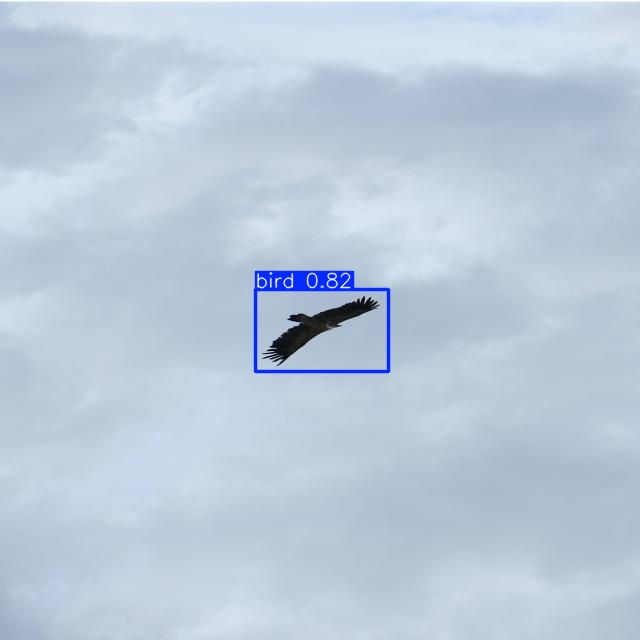

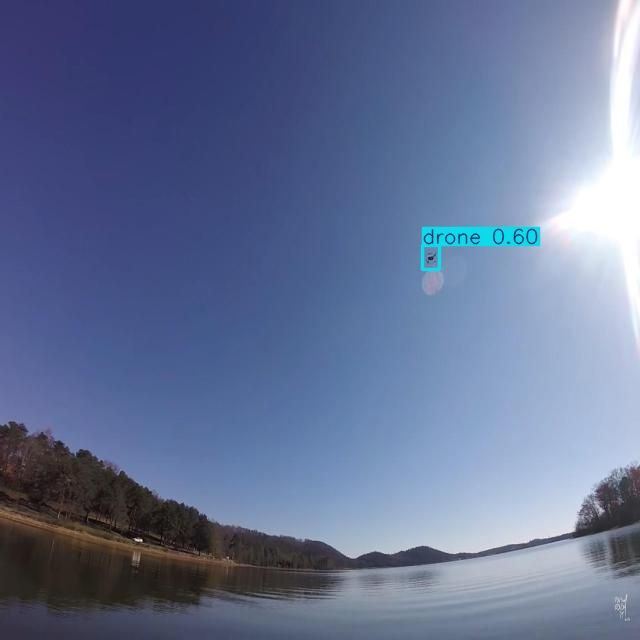

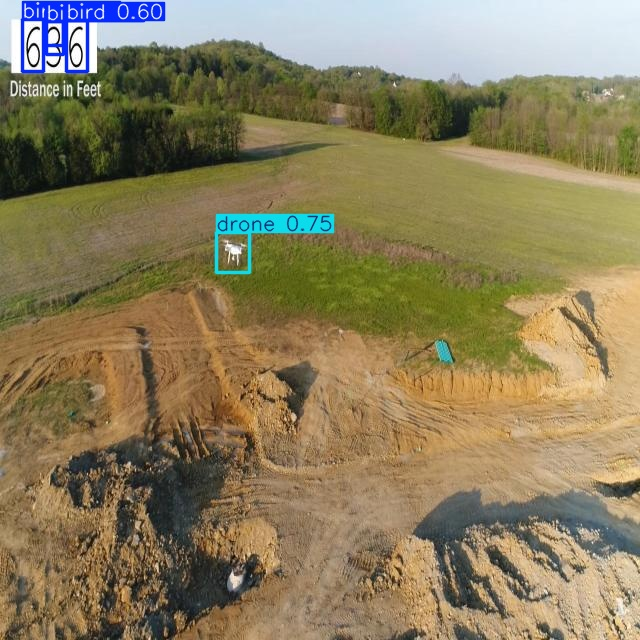

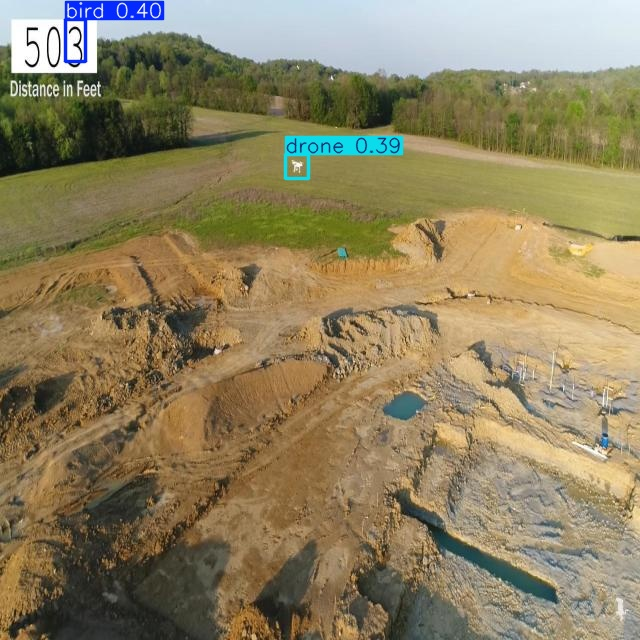

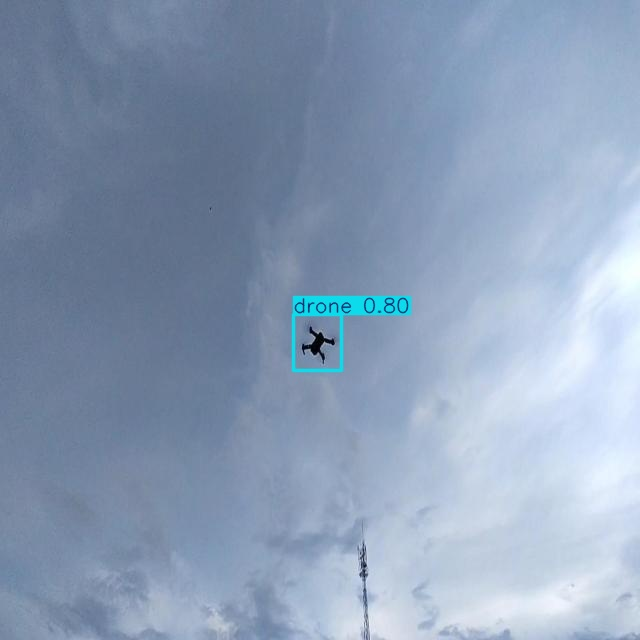


CHECK: do boxes match the correct class? (bird=0, drone=1)


In [12]:
import glob
import random

val_imgs = (glob.glob(f"{DATA_DIR}/val/images/*.jpg") +
            glob.glob(f"{DATA_DIR}/val/images/*.png"))
assert len(val_imgs) > 0, f"No validation images found at {DATA_DIR}/val/images/ — check Drive path."
sample   = random.sample(val_imgs, min(6, len(val_imgs)))

model_best = YOLO(best_s_dst)
INFER_OUT  = f"{RUNS_DIR}/inference_check"

preds = model_best.predict(
    source  = sample,
    conf    = 0.25,
    save    = True,
    project = INFER_OUT,
    name    = "val_sample",
    verbose = False,
)

saved = sorted(glob.glob(f"{INFER_OUT}/val_sample*/*.jpg") +
               glob.glob(f"{INFER_OUT}/val_sample*/*.png"))
for p in saved[:6]:
    display(IPImage(p, width=640))

print("\nCHECK: do boxes match the correct class? (bird=0, drone=1)")